In [1]:
import os
import chromadb
import warnings
warnings.filterwarnings("ignore")
from langchain_openai import OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.schema.runnable import RunnablePassthrough
from langchain.schema.output_parser import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.tools import TavilySearchResults
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain import hub
from langgraph.prebuilt import create_react_agent, ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, StateGraph, MessagesState, START
from langchain_core.tools import tool
from typing import Literal
from langchain_community.document_loaders import WebBaseLoader, TextLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import Graph
from langchain.vectorstores import Chroma
from pydantic import BaseModel, Field
from IPython.display import Image, display
from typing import List
from typing_extensions import TypedDict
from langchain.schema import Document
from langchain.tools.retriever import create_retriever_tool
from langgraph.prebuilt import tools_condition
from langchain_core.prompts import PromptTemplate


USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
load_dotenv()
embeddings = OpenAIEmbeddings()
parser = StrOutputParser()
llm = ChatOpenAI(model="gpt-4o-mini")

def displayGraph(app):
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        # This requires some extra dependencies and is optional
        print(e)

Create RAG Retriever

In [3]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=250, chunk_overlap=0
)
doc_splits = text_splitter.split_documents(docs_list)

# Add to vectorDB
vectorstore = Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chroma",
    embedding=OpenAIEmbeddings(),
)
retriever = vectorstore.as_retriever()

Create RAG Tool

In [4]:
retrieve=create_retriever_tool(
    retriever,
    "retrieve",
    "Search and return information about Lilian Weng blog posts on LLM agents, prompt engineering, and adversarial attacks on LLMs.You are a specialized assistant. Use the 'retriever_tool' **only** when the query explicitly relates to LangChain blog data. For all other queries, respond directly without using any tool. For simple queries like 'hi', 'hello', or 'how are you', provide a normal response.",
)

In [5]:
tools=[retrieve]
llm_with_tool = llm.bind_tools(tools)

Create RAG Chain

In [6]:
prompt = hub.pull("rlm/rag-prompt")
rag_chain = prompt | llm
question = "tell me about prompt engineering"

In [7]:
rag_chain.invoke({"context": retriever, "question": question})

AIMessage(content="Prompt engineering involves designing and refining prompts to improve the output of AI models, such as those from OpenAI. It aims to enhance the efficacy of the model's responses by providing clear and contextually relevant instructions. This practice is essential for maximizing the performance of language models in various applications.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 105, 'total_tokens': 163, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0392822090', 'id': 'chatcmpl-BOXSAcyIWu3GrBQmW0YBfwuTrf1QA', 'finish_reason': 'stop', 'logprobs': None}, id='run-1a87d811-f6f3-4a19-9bba-e73831085234-0', usage_metadata={'input_tokens': 105, 'output_tokens': 58, 'total_tokens':

Create Agentic Chain

In [8]:
system = """You are a helpful assistant whatever question has been asked to find out that in the given question and answer."""

agentic_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the question: \n\n {question}.",
        ),
    ]
)
agentic_chain = agentic_prompt | llm_with_tool

In [9]:
question = "What does the document refer about Agent Memory?"
result = agentic_chain.invoke({"question": question})
result

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_79cphbR9iFRahBUJ6rCtVNM2', 'function': {'arguments': '{"query":"Agent Memory"}', 'name': 'retrieve'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 168, 'total_tokens': 183, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_dbaca60df0', 'id': 'chatcmpl-BOXSBV3rgroQb5SnCxCLCnM19GZHp', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-1168aca8-1108-48df-a9b8-00d7fe093acc-0', tool_calls=[{'name': 'retrieve', 'args': {'query': 'Agent Memory'}, 'id': 'call_79cphbR9iFRahBUJ6rCtVNM2', 'type': 'tool_call'}], usage_metadata={'input_tokens': 168, 'output_tokens': 15, 'total_tokens': 183, 'input_token_details': {'audio': 0, 'cache_re

In [11]:
question = "What's the capital of USA?"
result = agentic_chain.invoke({"question": question})
result

AIMessage(content='The capital of the USA is Washington, D.C.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 165, 'total_tokens': 178, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_dbaca60df0', 'id': 'chatcmpl-BOXSC6ldOWFGD6lKi5TGrCAE3fCXD', 'finish_reason': 'stop', 'logprobs': None}, id='run-6aefc8a5-fd9d-4be8-85c4-19f64cf289eb-0', usage_metadata={'input_tokens': 165, 'output_tokens': 13, 'total_tokens': 178, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

Create Grader Retriever Chain

In [14]:
class GradeDocuments(BaseModel):
    """Tests whether the documents are relevant or not"""
    binary_score: str = Field(description="Documents are relevant to the question, 'yes' or 'no'")

In [15]:
structured_llm_grader = llm.with_structured_output(GradeDocuments)

In [16]:
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)
retrieval_grader_chain = grade_prompt | structured_llm_grader

In [32]:
question = "agent memory"
docs = retriever.get_relevant_documents(question)
retrieval_grader_chain.invoke({"question": question, "document": docs})

GradeDocuments(binary_score='yes')

In [33]:
question = "What's the capital of India?"
retrieval_grader_chain.invoke({"question": question, "document": docs})

GradeDocuments(binary_score='no')

Create Question Re-writer Retriever Chain

In [19]:
system = """You a question re-writer that converts an input question to a better version that is optimized \n
Look at the input and try to reason about the underlying semantic intent / meaning."""

re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)
question_rewriter_chain = re_write_prompt | llm

In [20]:
question_rewriter_chain.invoke({"question": question})

AIMessage(content='What is the capital city of India?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 66, 'total_tokens': 75, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_dbaca60df0', 'id': 'chatcmpl-BOXSFoSJbZgyxs2FsSL2pyZtKYzOc', 'finish_reason': 'stop', 'logprobs': None}, id='run-eae7f6da-3416-45e5-a7a7-32b73cef1cbf-0', usage_metadata={'input_tokens': 66, 'output_tokens': 9, 'total_tokens': 75, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

Functions

In [21]:
def agent(state):
    """Determines whether we need to use the tool or not. Invoke the tool if needed, if not then just answer to the question."""
    print("---CALL AGENT---")
    messages = state["messages"]
    last_message = messages[-1]
    question = last_message.content
    result = agentic_chain.invoke({"question": question})
    return { "messages": [result] }
    

In [22]:
def generate(state):
    """Generate answer"""
    print("---GENERATE---")
    messages = state["messages"]
    first_message = messages[0]
    last_message = messages[-1]
    question = first_message.content
    documents = last_message.content
    result = rag_chain.invoke({"context": documents, "question": question})
    return {"messages": [result]}

In [23]:
def rewrite(state):
    """Transform the query to produce a better question."""
    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    first_message = messages[0]
    question = first_message.content
    response = question_rewriter_chain.invoke({"question": question})
    return {"messages": [response]}

Create Routers

In [24]:
def grader_router(state):
    """Determines whether the documents are relevant or not."""
    messages = state["messages"]
    first_message = messages[0]
    last_message = messages[-1]
    question = first_message.content
    documents = last_message.content
    response = retrieval_grader_chain.invoke({"question": question, "document": documents})
    if response.binary_score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generator"
    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        return "rewriter"


In [25]:
workflow= StateGraph(MessagesState)

workflow.add_node("agent", agent)  # agent
workflow.add_node("retrieve", ToolNode(tools))  # retrieve
workflow.add_node("generate", generate)  # generate
workflow.add_node("rewrite", rewrite)  # rewrite

workflow.set_entry_point("agent")
workflow.add_conditional_edges(
    "agent",
    tools_condition,
    {
        "tools": "retrieve",
        END: END
    },
)
workflow.add_conditional_edges(
    "retrieve",
    grader_router,
    {
        "generator": "generate",
        "rewriter": "rewrite"
    },
)
workflow.add_edge("rewrite", "agent")
workflow.add_edge("generate", END)

app = workflow.compile()

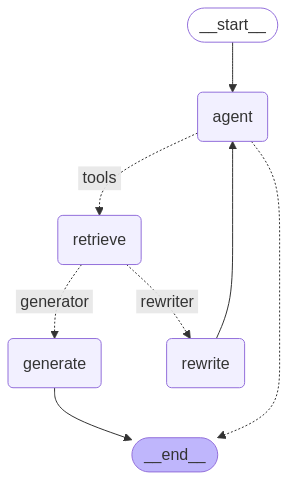

In [26]:
displayGraph(app)

In [27]:
result = app.invoke({"messages": ["What's the capital of India?"]})

---CALL AGENT---


In [28]:
result

{'messages': [HumanMessage(content="What's the capital of India?", additional_kwargs={}, response_metadata={}, id='cdd512e4-a5c2-4660-8779-564b377aec29'),
  AIMessage(content='The capital of India is New Delhi.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 165, 'total_tokens': 175, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_dbaca60df0', 'id': 'chatcmpl-BOXSGrpYN0gnGL3VxfwElVz8y43Pd', 'finish_reason': 'stop', 'logprobs': None}, id='run-92d2abc1-b867-4f04-b3a1-110d621ad4b6-0', usage_metadata={'input_tokens': 165, 'output_tokens': 10, 'total_tokens': 175, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [29]:
result = app.invoke({"messages": ["What does the document refer about Agent Memory??"]})

---CALL AGENT---
---DECISION: DOCS RELEVANT---
---GENERATE---


In [30]:
result

{'messages': [HumanMessage(content='What does the document refer about Agent Memory??', additional_kwargs={}, response_metadata={}, id='4e9d9e70-568b-46dd-bd48-b6f697b03e4e'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_gj03IGLoJPI1SQgJboZlkwdL', 'function': {'arguments': '{"query":"Agent Memory"}', 'name': 'retrieve'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 169, 'total_tokens': 184, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_dbaca60df0', 'id': 'chatcmpl-BOXSGBybxlCaeouYkA0jWrbrmoIsk', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-86bee20d-81f8-4efc-893e-5765ee71de06-0', tool_calls=[{'name': 'retrieve', 'args': {'query': 'Agent Memory'}, 'id': 'c

In [31]:
app.invoke({"messages":["What is a Autonomous Agent?"]})

---CALL AGENT---


{'messages': [HumanMessage(content='What is a Autonomous Agent?', additional_kwargs={}, response_metadata={}, id='3b023600-d6d7-47ac-b247-5c7da423434e'),
  AIMessage(content='An autonomous agent is a system or entity that can operate independently to perform tasks or make decisions without direct human intervention. Autonomous agents use various technologies such as artificial intelligence, machine learning, and robotics to perceive their environment, plan actions, and execute tasks based on their goals. These agents can adapt to new situations, learn from experiences, and usually operate in dynamic and complex environments.\n\nExamples of autonomous agents include self-driving cars, drones that can navigate and complete delivery tasks, and software bots that can automate processes in various applications.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 106, 'prompt_tokens': 165, 'total_tokens': 271, 'completion_tokens_details': {'accepted